2026-08-15 17:25:47.382 | INFO     | __main__:sub_node:12 - [子图] sub_node 执行
2026-08-15 17:25:47.383 | INFO     | __main__:node_b:33 - [父图] node_b 执行



最终结果: {'data': '初始 → 子图'}


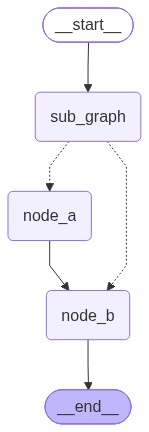

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_a(node_a)
	node_b(node_b)
	__end__([<p>__end__</p>]):::last
	__start__ --> sub_graph\3asub_node;
	node_a --> node_b;
	sub_graph\3asub_node -.-> node_a;
	sub_graph\3asub_node -.-> node_b;
	node_b --> __end__;
	subgraph sub_graph
	sub_graph\3asub_node(sub_node)
	end
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from loguru import logger

# ==================== 子图 ====================
class SubState(TypedDict):
    data: str

def sub_node(state: SubState) -> Command:
    """子图节点：执行后动态路由回父图的 parent_router"""
    logger.info("[子图] sub_node 执行")
    return Command(
        update={"data": state["data"] + " → 子图"},
        goto="node_b",       # 路由到父图节点
        graph=Command.PARENT,       # 指定目标为父图
    )

sub_builder = StateGraph(state_schema=SubState)
sub_builder.add_node("sub_node", sub_node)
sub_builder.add_edge(START, "sub_node")
sub_graph = sub_builder.compile()

# ==================== 父图 ====================
class ParentState(TypedDict):
    data: str

def node_a(state: ParentState) -> ParentState:
    logger.info("[父图] node_a 执行")
    return {"visited_a": True}

def node_b(state: ParentState) -> ParentState:
    logger.info("[父图] node_b 执行")
    return {"visited_b": True}

parent_builder = StateGraph(state_schema=ParentState)
parent_builder.add_node(
    "sub_graph", sub_graph,destinations=("node_a","node_b")
)

parent_builder.add_node("node_a", node_a)
parent_builder.add_node("node_b", node_b)
parent_builder.add_edge(START, "sub_graph")
# parent_builder.add_edge("sub_graph","node_a")
parent_builder.add_edge("node_a", "node_b")
parent_builder.add_edge("node_b", END)

parent_graph = parent_builder.compile()

result = parent_graph.invoke({"data": "初始"})
print(f"\n最终结果: {result}")

from IPython.display import display
display(parent_graph)
raw_mermaid = parent_graph.get_graph(xray=True).draw_mermaid()
print(raw_mermaid)